In [ ]:
# main.py
# ─────────────────────────────────────────────────────────────────────────────
# Orchestrates the full solenoid design-space study.
#
#   Run in Jupyter/IPython to utilize interactive widgets.
# ─────────────────────────────────────────────────────────────────────────────
%matplotlib widget

import importlib

# Hot-reload local modules, dependency-first, so a reloaded module never holds
# references to a stale version of something below it.
import config
importlib.reload(config)

import solenoid_lib
importlib.reload(solenoid_lib)

import grid
importlib.reload(grid)

import io_grids
importlib.reload(io_grids)

import plots_thickness
importlib.reload(plots_thickness)

import plots_area
importlib.reload(plots_area)


# Define the lengths (in meters) to iterate over
LENGTHS_M = [5.0]  # meters


def main():
    all_grids = {}

    for L in LENGTHS_M:
        print(f"\n=== Solenoid Length = {L*1e3:.0f} mm ===")

        # 1. Update the physics library with the current length
        solenoid_lib.solenoid_length = L
        label = f"L{int(round(L*1e3))}mm"

        # 2. Build the meshgrids based on Thickness
        a_grids = grid.build_thickness_grid()

        # 3. Save the results to the newly formatted CSV
        csv_filename = f"thickness_grids_{label}.csv"
        io_grids.save_grids_long(a_grids, csv_filename, solenoid_length=L)

        # 4. Generate all the requested contour plots
        #plots_thickness.plot_all(a_grids, label=label, solenoid_length_m=L)

        # Store for return
        all_grids[L] = a_grids

    return all_grids


if __name__ == "__main__":
    # Run the main loop
    all_grids = main()


=== Solenoid Length = 1000 mm ===
Th-scan axes:
  Ri          :   3 pts, 10.000 – 1500.000 mm, step 745.000 → 745.000 mm (uniform) (uniform would be 745.000)
  Th          :   3 pts, 2.000 – 400.000 mm, step 99.500 → 298.500 mm (coarsening) (uniform would be 199.000)
  9/9  (100%)
2-D meshgrid (Th-scan) computed.
  Valid cells     : 9 / 9
  Converged cells : 9 / 9
  Ri              : 10.0 – 1500.0 mm
  Th (mm)         : 2.00 – 400.00
  f_tape_min (%)  : 14.36 – 87.52
  Len tape (km)   : 0.13 – 1022.89
  B0              : 1.585 – 87.544 T
  Stress          : 17.5 – 750.0 MPa
Saved raw grids -> thickness_grids_L1000mm.csv  (9 cells)


In [373]:
def report(rep, g, show_plots=True):
    try:
        import pandas as pd
        from IPython.display import display, Markdown
    except ImportError:
        return _report_text(rep)

    tick = lambda b: "—" if b is None else ("✓" if b else "✗ FAIL")

    display(Markdown(f"### Recomputation — {rep['n']} live cells, rtol {RTOL:g}"))
    df = pd.DataFrame([
        dict(field=k, max_rel_err=v["max_rel"], n_bad=v["n_bad"],
             worst_cell=str(v["worst_cell"]), saved=v["got"], recomputed=v["want"],
             ok=tick(v["n_bad"] == 0))
        for k, v in rep["fields"].items()]).set_index("field")
    display(df.style.format({"max_rel_err": "{:.2e}", "saved": "{:.6g}",
                             "recomputed": "{:.6g}"}))

    display(Markdown("### Invariants"))
    display(pd.DataFrame([dict(check=k, ok=tick(v), detail=d)
                          for k, (v, d) in rep["invariants"].items()]).set_index("check"))

    display(Markdown("### Provenance (archive vs. current library)"))
    display(pd.DataFrame([dict(constant=k, in_file=s, in_library=c, ok=tick(o))
                          for k, (s, c, o) in rep["provenance"].items()]).set_index("constant"))

    r = rep["resid"]
    display(Markdown(
        f"### Fixed-point residual  `(Je_tape(B0) - je_coil)/je_coil`\n"
        f"EM-limited cells: **{len(r)}** ({100*rep['em_frac']:.1f}%) &nbsp;·&nbsp; "
        f"median **{np.median(r):+.3%}** &nbsp;·&nbsp; "
        f"range **{r.min():+.3%} … {r.max():+.3%}**\n\n"
        f"_Zero at a true fixed point. Nonzero and smoothly varying ⇒ the loop is "
        f"exiting early, not converging._"))

    if show_plots:
        _plots(rep, g)


def _plots(rep, g):
    import matplotlib.pyplot as plt
    m, rec = rep["mask"], rep["rec"]
    x = g["ri_vals"]
    y = g["th_vals"] if "th_vals" in g else g["a_vals"]
    ylab = "Th [m]" if "th_vals" in g else "A [m$^2$]"
    ext = [x[0], x[-1], y[0], y[-1]]

    resid = np.where(m, (rec["je_max"] - g["je_coil"]) / g["je_coil"], np.nan)
    resid[g["je_coil"] >= rec["je_mech"] * (1 - 1e-9)] = np.nan     # stress-limited: N/A

    fig, ax = plt.subplots(1, 3, figsize=(15, 4.2), constrained_layout=True)
    for a, arr, t, cm in (
            (ax[0], np.where(m, g["b0"], np.nan),     "B0 [T]",              "viridis"),
            (ax[1], np.where(m, g["stress"], np.nan), f"hoop [MPa], limit {SLIM:.0f}", "magma"),
            (ax[2], 100 * resid,                      "fixed-point resid [%]", "coolwarm")):
        im = a.imshow(arr, origin="lower", aspect="auto", extent=ext, cmap=cm)
        a.set_title(t); a.set_xlabel("Ri [m]"); a.set_ylabel(ylab)
        fig.colorbar(im, ax=a)
    # overlay the mechanical-limit boundary
    ax[1].contour(x, y, np.where(m, g["je_coil"] / rec["je_mech"], np.nan),
                  levels=[1 - 1e-9], colors="w", linewidths=1.2)
    plt.show()


def _report_text(rep):
    for k, v in rep["fields"].items():
        print(f"  {k:<12} max_rel {v['max_rel']:.2e}  bad {v['n_bad']}")
    for k, (v, d) in rep["invariants"].items():
        print(f"  {k:<20} {'OK ' if v else 'FAIL'} {d}")

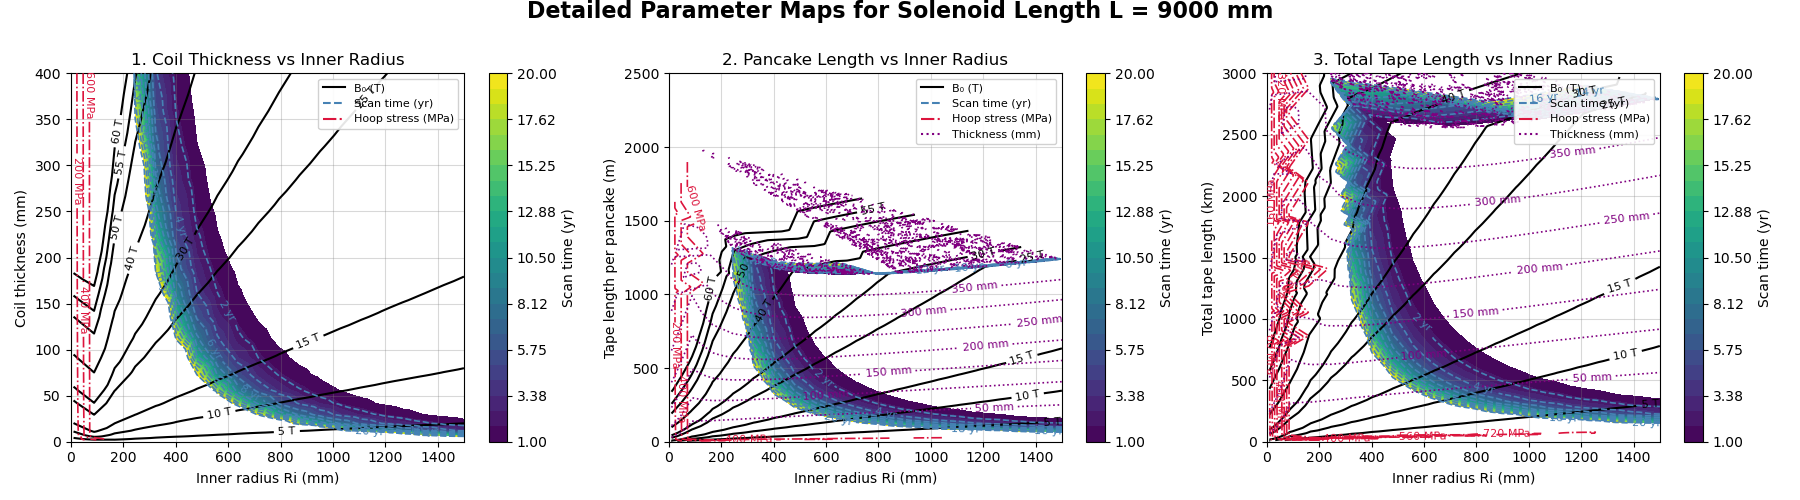

In [ ]:
%matplotlib widget
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.interpolate import griddata
import glob

# -------------------------------------------------------------------------
# 1. LOAD DATA
#    Legacy "sc" column names are remapped per-file, before the concat, so
#    that a mix of old and new CSVs lines up on the same columns instead of
#    producing two half-NaN columns.
# -------------------------------------------------------------------------
_LEGACY_RENAMES = {
    "f_sc": "f_tape_min",
    "length_sc": "length_tape",
    "je_sc": "je_tape",
    "a_sc": "a_tape",
    "rebco_pancake_length": "tape_pancake_length",
    "length_tape_km": "length_tape_km",   # derived col, written by io_grids
}

def _read_grid_csv(path):
    df = pd.read_csv(path)
    hits = {k: v for k, v in _LEGACY_RENAMES.items() if k in df.columns}
    if hits:
        pairs = ", ".join(f"{k}->{v}" for k, v in hits.items())
        print(f"[!] {path}: legacy columns remapped ({pairs})")
        df = df.rename(columns=hits)
    return df

file_list = sorted(glob.glob('thickness_grids_L*.csv'))
if not file_list:
    raise FileNotFoundError("No thickness_grids_L*.csv found in the working directory.")
df_all = pd.concat((_read_grid_csv(f) for f in file_list), ignore_index=True)

# -------------------------------------------------------------------------
# 2. HELPER FUNCTIONS (Interactivity & Regridding)
# -------------------------------------------------------------------------
def setup_grid_annotation(fig, scatters, data_dfs, active_axes):
    annots = []
    for ax in active_axes:
        annot = ax.annotate("", xy=(0, 0), xytext=(15, 15), textcoords="offset points",
                            bbox=dict(boxstyle="round", fc="w", alpha=0.9), fontsize=8, zorder=10)
        annot.set_visible(False)
        annots.append(annot)

    def on_pick(event):
        # Hide all annotations first
        for ann in annots:
            ann.set_visible(False)

        # Find which scatter point was clicked/hovered
        for i, scat in enumerate(scatters):
            if event.artist == scat:
                ind = event.ind[0]
                row = data_dfs[i].iloc[ind]
                x, y = event.artist.get_offsets()[ind]

                text = (f"L={row['solenoid_length_m']:.1f} m\n"
                        f"Ri={row['ri']:.3f} m, Th={row['th']:.3f} m\n"
                        f"B0={row['b0']:.2f} T\n"
                        f"Total tape={row['length_tape_km']:.1f} km\n"
                        f"Pancake={row['pancake_length_m']:.1f} m\n"
                        f"Scan={row['scan']:.1f} yrs")

                annots[i].xy = (x, y)
                annots[i].set_text(text)
                annots[i].set_visible(True)
                fig.canvas.draw_idle()
                break

    fig.canvas.mpl_connect("pick_event", on_pick)


def _regrid(x, y, z, nx=400, ny=400):
    xf, yf, zf = np.asarray(x).flatten(), np.asarray(y).flatten(), np.asarray(z).flatten()
    mask = np.isfinite(xf) & np.isfinite(yf) & np.isfinite(zf)

    if not mask.any():
        xi = np.linspace(np.nanmin(xf) if len(xf) else 0, np.nanmax(xf) if len(xf) else 1, nx)
        yi = np.linspace(np.nanmin(yf) if len(yf) else 0, np.nanmax(yf) if len(yf) else 1, ny)
        xi2d, yi2d = np.meshgrid(xi, yi)
        return xi2d, yi2d, np.full_like(xi2d, np.nan)

    xi = np.linspace(np.nanmin(xf[mask]), np.nanmax(xf[mask]), nx)
    yi = np.linspace(np.nanmin(yf[mask]), np.nanmax(yf[mask]), ny)
    xi2d, yi2d = np.meshgrid(xi, yi)
    zi2d = griddata((xf[mask], yf[mask]), zf[mask], (xi2d, yi2d), method="linear")
    return xi2d, yi2d, zi2d


def draw_contours(ax, x, y, df, plot_type):
    scan_limit = 20.0
    scan_levels = np.linspace(1, scan_limit, 25)
    scan_line_levels = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]

    field_line_levels = [5, 10, 15, 25, 30, 40, 50, 55, 60]

    th_line_levels = [50, 100, 150, 200, 250, 300, 350, 400]

    # 1. Scan time background map
    xi, yi, zi_scan = _regrid(x, y, df['scan'])
    zi_scan_masked = np.where((zi_scan > 0) & (zi_scan <= scan_limit), zi_scan, np.nan)
    cntr = ax.contourf(xi, yi, zi_scan_masked, levels=scan_levels, cmap='viridis', zorder=1)

    # 2. Magnetic Field (B0)
    _, _, zi_b0 = _regrid(x, y, df['b0'])
    if np.isfinite(zi_b0).any():
        iso_b0 = ax.contour(xi, yi, zi_b0, colors='black', linewidths=1.5, levels=field_line_levels, zorder=3)
        ax.clabel(iso_b0, inline=True, fmt='%.0f T', fontsize=8, colors='black')

    # 3. Scan Time (Lines)
    if np.isfinite(zi_scan).any():
        iso_scan = ax.contour(xi, yi, zi_scan, colors='steelblue', linestyles='dashed', linewidths=1.2, levels=scan_line_levels, zorder=3)
        ax.clabel(iso_scan, inline=True, fmt='%.0f yr', fontsize=8, colors='steelblue')

    # 4. Hoop Stress
    stress_levels = 10 if plot_type == 3 else 3
    _, _, zi_stress = _regrid(x, y, df['stress'])
    if np.isfinite(zi_stress).any():
        iso_stress = ax.contour(xi, yi, zi_stress, colors='crimson', linestyles='dashdot', linewidths=1.2, levels=stress_levels, zorder=3)
        ax.clabel(iso_stress, inline=True, fmt='%.0f MPa', fontsize=8, colors='crimson')

    # 5. Thickness (Only for Graphs 2 and 3)
    if plot_type in [2, 3]:
        _, _, zi_th = _regrid(x, y, df['th'] * 1000)
        if np.isfinite(zi_th).any():
            iso_th = ax.contour(xi, yi, zi_th, colors='purple', linestyles='dotted', linewidths=1.2, levels=th_line_levels, zorder=3)
            ax.clabel(iso_th, inline=True, fmt='%.0f mm', fontsize=8, colors='purple')

    return cntr

# -------------------------------------------------------------------------
# 3. MAIN PLOTTING FUNCTION
# -------------------------------------------------------------------------
def plot_selected_length(target_length_m, df_full):
    # Filter the DataFrame for the selected length
    df_sub = df_full[df_full['solenoid_length_m'] == target_length_m].reset_index(drop=True)

    if df_sub.empty:
        print(f"No data found for L = {target_length_m} m.")
        print(f"Available lengths are: {sorted(df_full['solenoid_length_m'].unique())}")
        return

    # Create the 1x3 figure
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))
    fig.suptitle(f'Detailed Parameter Maps for Solenoid Length L = {target_length_m*1000:.0f} mm', fontsize=16, fontweight='bold', y=1)

    x_mm = df_sub['ri'] * 1000
    scats = []

    # Legend Elements
    leg1 = [
        Line2D([0], [0], color='black', lw=1.5, label='B₀ (T)'),
        Line2D([0], [0], color='steelblue', lw=1.5, linestyle='--', label='Scan time (yr)'),
        Line2D([0], [0], color='crimson', lw=1.5, linestyle='-.', label='Hoop stress (MPa)')
    ]
    leg23 = leg1 + [Line2D([0], [0], color='purple', lw=1.5, linestyle=':', label='Thickness (mm)')]

    # Graph 1: Coil Thickness
    ax1 = axes[0]
    y1_mm = df_sub['th'] * 1000
    cntr1 = draw_contours(ax1, x_mm, y1_mm, df_sub, plot_type=1)
    fig.colorbar(cntr1, ax=ax1, label='Scan time (yr)')

    ax1.set_xlabel('Inner radius Ri (mm)')
    ax1.set_ylabel('Coil thickness (mm)')
    ax1.set_title('1. Coil Thickness vs Inner Radius')
    ax1.legend(handles=leg1, loc='upper right', framealpha=0.9, fontsize=8).set_zorder(4)
    ax1.grid(True, linestyle='-', color='gray', alpha=0.3, zorder=2)
    scats.append(ax1.scatter(x_mm, y1_mm, color='white', alpha=0.0, picker=5, zorder=5))
    ax1.set_xlim(0, 1500)  # Set x-axis limit to 1500 mm
    ax1.set_ylim(0, 400)   # Set y-axis limit to 400 mm

    # Graph 2: Pancake Length
    ax2 = axes[1]
    y2_m = df_sub['pancake_length_m']
    cntr2 = draw_contours(ax2, x_mm, y2_m, df_sub, plot_type=2)
    fig.colorbar(cntr2, ax=ax2, label='Scan time (yr)')

    ax2.set_xlabel('Inner radius Ri (mm)')
    ax2.set_ylabel('Tape length per pancake (m)')
    ax2.set_title('2. Pancake Length vs Inner Radius')
    ax2.legend(handles=leg23, loc='upper right', framealpha=0.9, fontsize=8).set_zorder(4)
    ax2.grid(True, linestyle='-', color='gray', alpha=0.3, zorder=2)
    scats.append(ax2.scatter(x_mm, y2_m, color='white', alpha=0.0, picker=5, zorder=5))
    ax2.set_xlim(0, 1500)  # Set x-axis limit to 1500 mm
    ax2.set_ylim(0, 2500)  # Set y-axis limit to 2500 m


    # Graph 3: Total Tape Length
    ax3 = axes[2]
    y3_km = df_sub['length_tape_km']
    cntr3 = draw_contours(ax3, x_mm, y3_km, df_sub, plot_type=3)
    fig.colorbar(cntr3, ax=ax3, label='Scan time (yr)')

    ax3.set_xlabel('Inner radius Ri (mm)')
    ax3.set_ylabel('Total tape length (km)')
    ax3.set_title('3. Total Tape Length vs Inner Radius')
    ax3.legend(handles=leg23, loc='upper right', framealpha=0.9, fontsize=8).set_zorder(4)
    ax3.grid(True, linestyle='-', color='gray', alpha=0.3, zorder=2)
    scats.append(ax3.scatter(x_mm, y3_km, color='white', alpha=0.0, picker=5, zorder=5))
    ax3.set_xlim(0, 1500)  # Set x-axis limit to 1500 mm
    ax3.set_ylim(0, 3000)  # Set y-axis limit to 3000 km

    # Connect interactivity and adjust layout
    setup_grid_annotation(fig, scats, [df_sub, df_sub, df_sub], axes)
    fig.tight_layout()
    plt.show()

# -------------------------------------------------------------------------
# 4. EXECUTE PLOT
# Change the length below to map a different target length (e.g. 5.0, 6.0)
# -------------------------------------------------------------------------
selected_length = 9.0
plot_selected_length(selected_length, df_all)

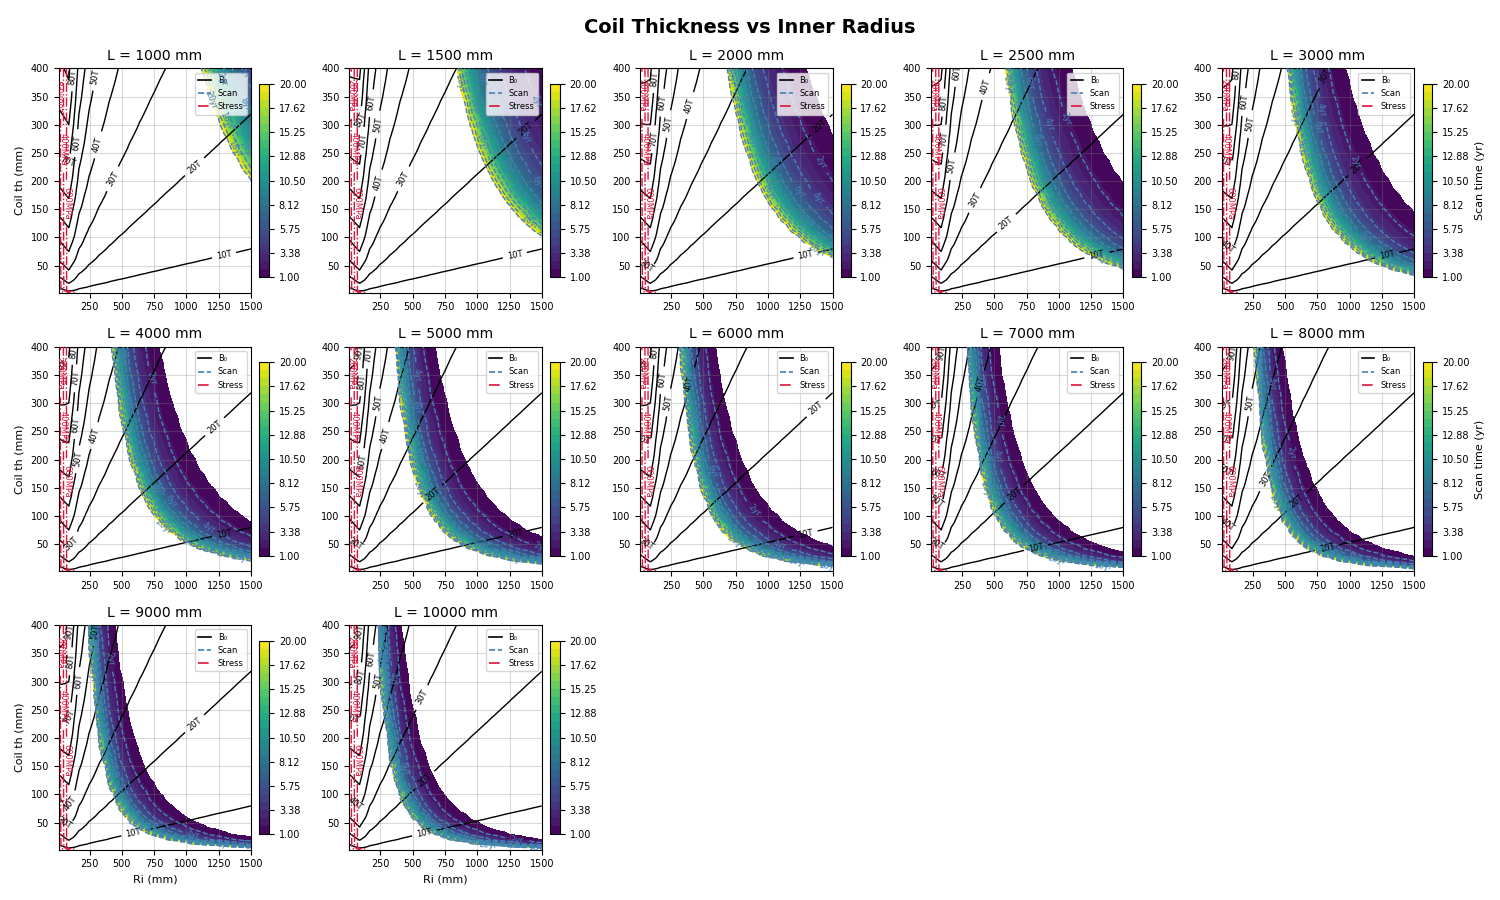

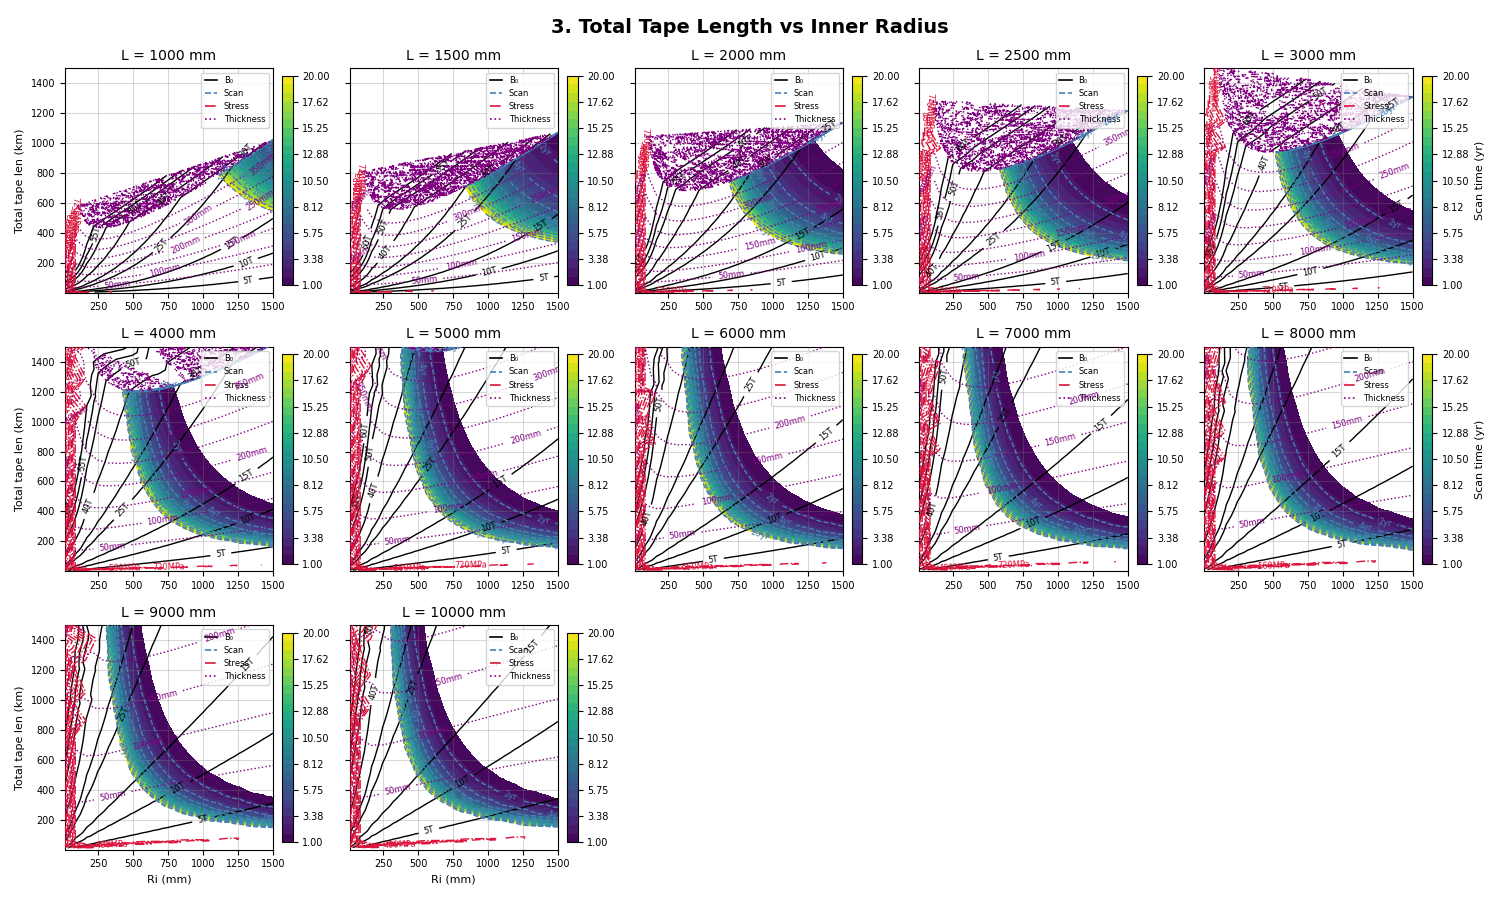

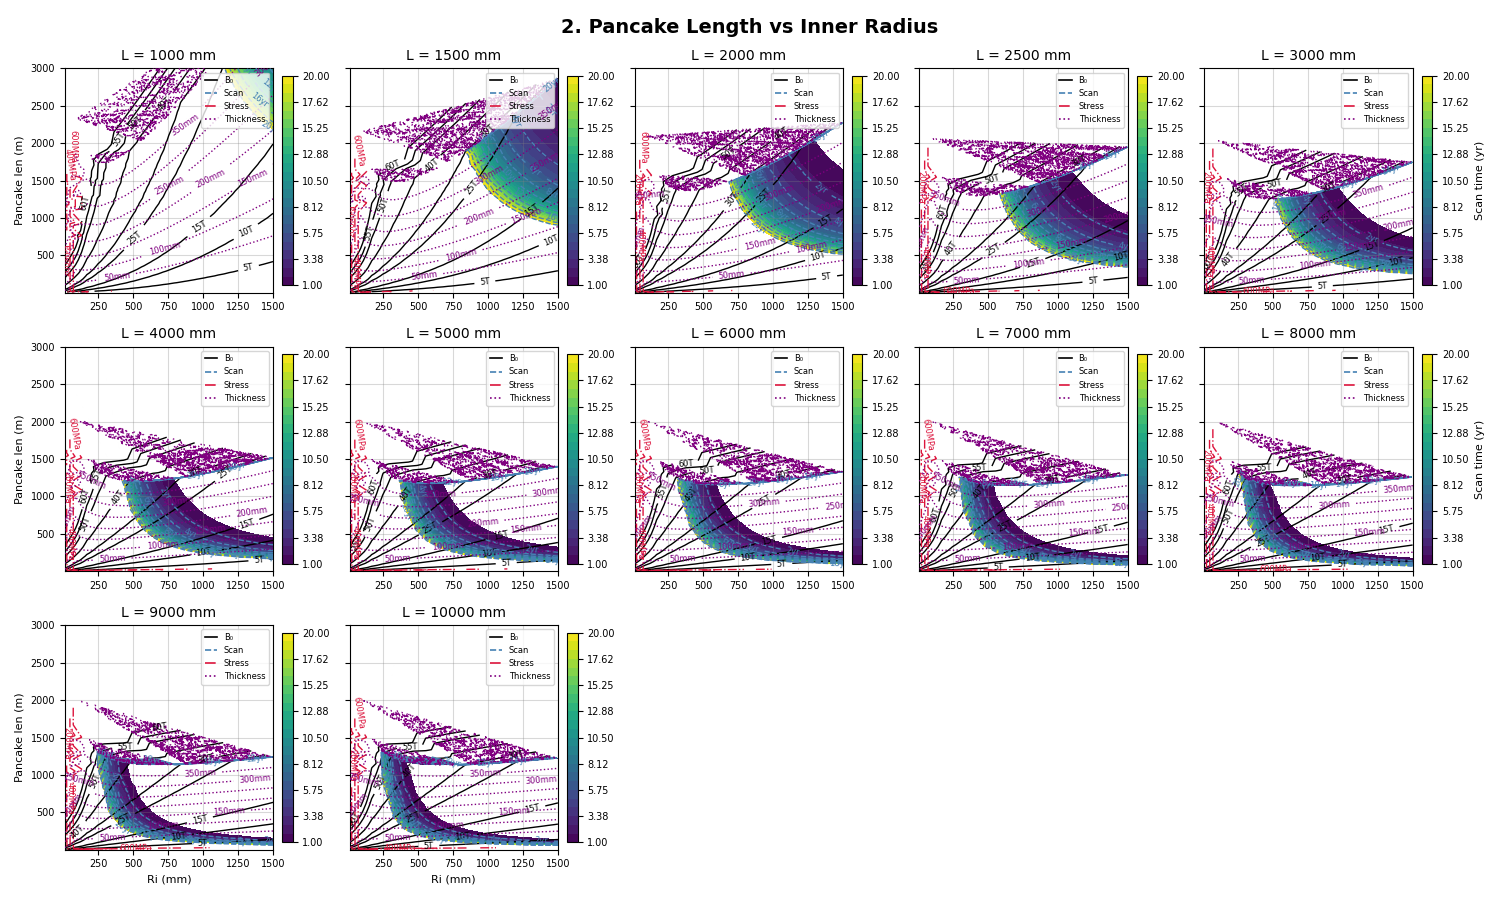

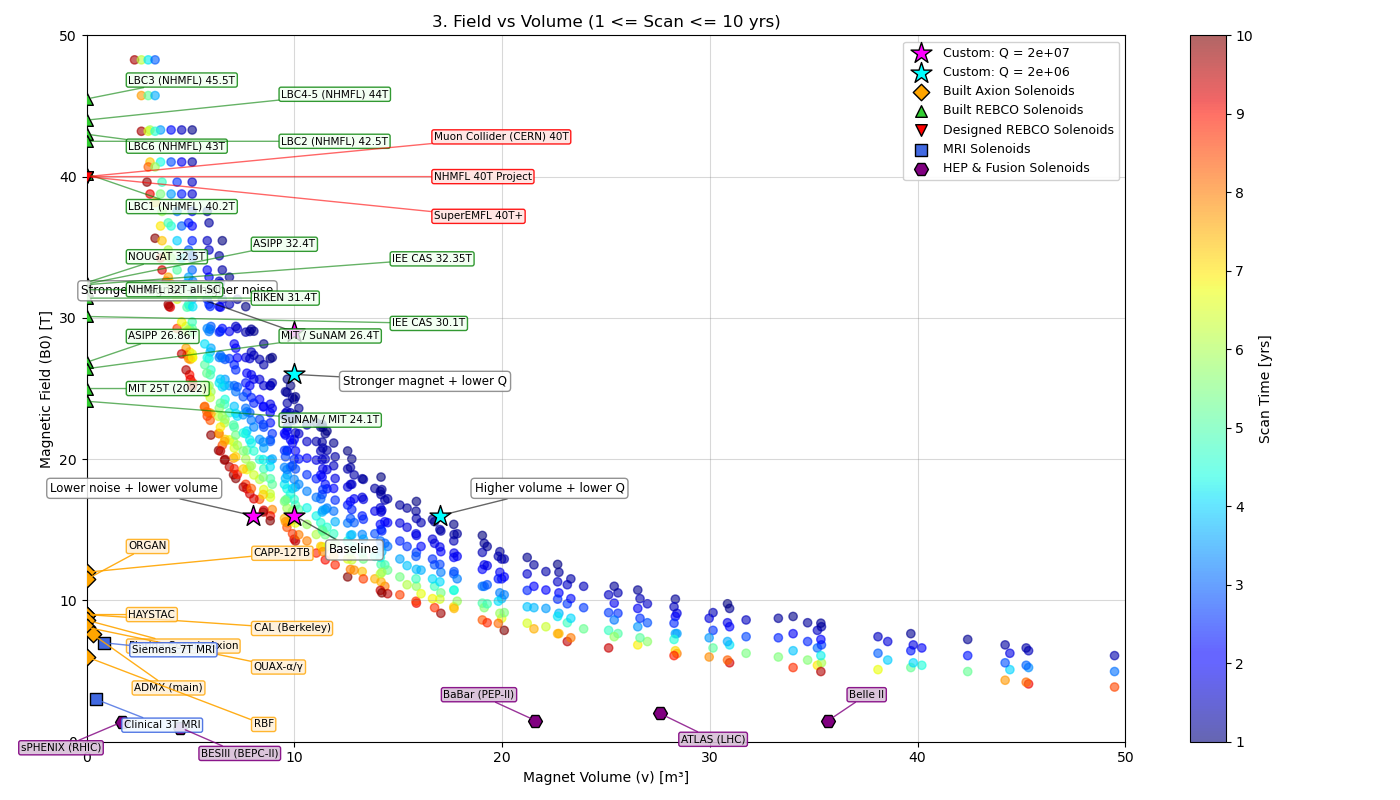

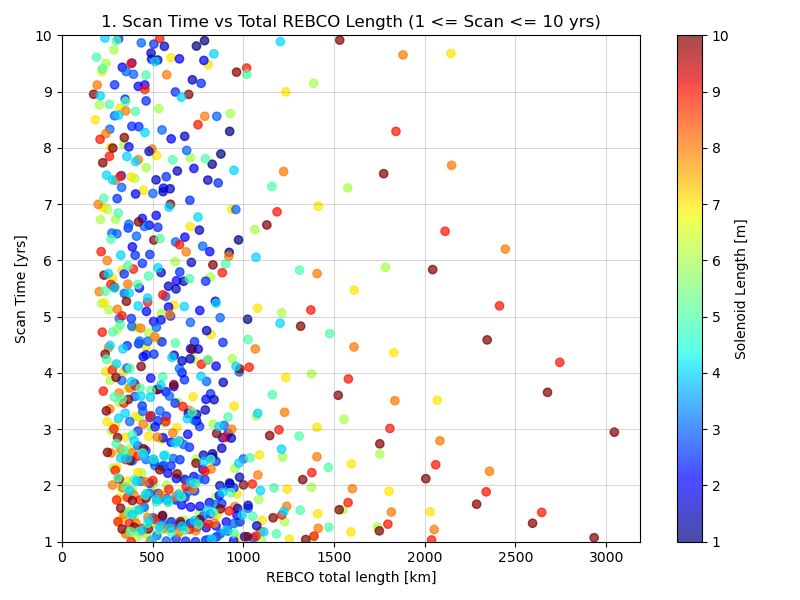

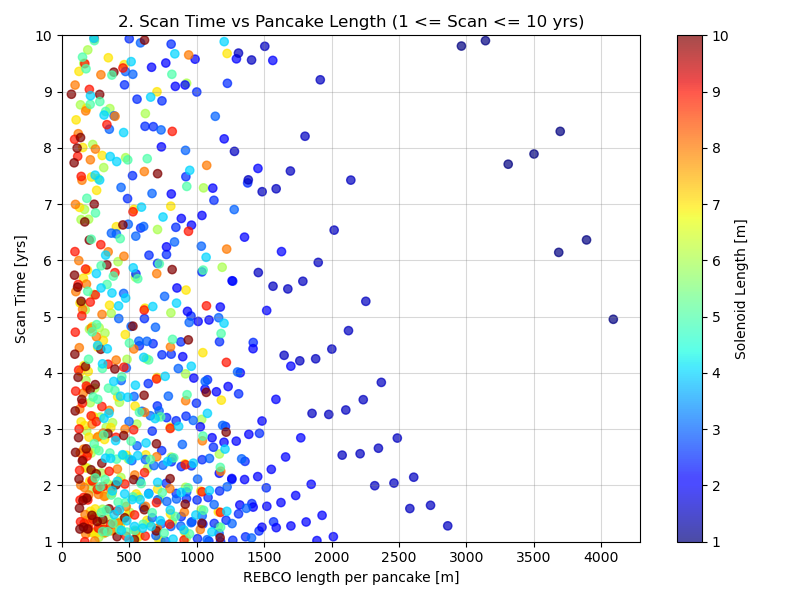

In [364]:
# -------------------------------------------------------------------------
# GLOBAL SCATTER PLOTS (Figs 1, 2, 3)
# -------------------------------------------------------------------------
import matplotlib.pyplot as plt


# -------------------------------------------------------------------------
# 1. LOAD DATA
# -------------------------------------------------------------------------
file_list = glob.glob('thickness_grids_L*.csv')
df_all = pd.concat((pd.read_csv(f) for f in file_list), ignore_index=True)


def setup_single_annotation(fig, ax, scatter_obj, data_df):
    annot = ax.annotate("", xy=(0, 0), xytext=(15, 15), textcoords="offset points",
                        bbox=dict(boxstyle="round", fc="w", alpha=0.9), fontsize=8, zorder=10)
    annot.set_visible(False)

    def on_pick(event):
        if event.artist != scatter_obj:
            return
            
        ind = event.ind[0]
        row = data_df.iloc[ind]

        x, y = event.artist.get_offsets()[ind]
        
        text = (f"L={row['solenoid_length_m']:.1f} m\n"
                f"Ri={row['ri']:.3f} m, Th={row['th']:.3f} m\n"
                f"B0={row['b0']:.2f} T\n"
                f"Total SC={row['length_tape_km']:.1f} km\n"
                f"Pancake SC={row['pancake_length_m']:.1f} m\n"
                f"Scan={row['scan']:.1f} yrs\n"
                f"Vol={row.get('v', 0):.2f}")

        annot.xy = (x, y)
        annot.set_text(text)
        annot.set_visible(True)
        fig.canvas.draw_idle()

    fig.canvas.mpl_connect("pick_event", on_pick)


# --- 1. FILTERING & AXIS CONTROLS ---

# Filter out magnets with a scan time outside the 1 to 10 year range
min_scan_years = 1.0
max_scan_years = 10.0
df_filtered = df_all[(df_all['scan'] >= min_scan_years) & (df_all['scan'] <= max_scan_years)].reset_index(drop=True)

# Axis limits for Graph 1 & 2
g1_xlim = (0, None)
g1_ylim = (min_scan_years, max_scan_years)
g2_xlim = (0, None)
g2_ylim = (min_scan_years, max_scan_years)

# Axis limits for Graph 3
g3_xlim = (0, 50) 
g3_ylim = (0, 50) 


# -------------------------------------------------------------------------
# 1. Scan time vs REBCO total length 
# -------------------------------------------------------------------------

fig1, ax1 = plt.subplots(figsize=(8, 6))
scat1 = ax1.scatter(df_filtered['length_tape_km'], df_filtered['scan'], 
                    c=df_filtered['solenoid_length_m'], cmap='jet', alpha=0.7, picker=5)
fig1.colorbar(scat1, ax=ax1, label='Solenoid Length [m]')
ax1.set_xlabel('REBCO total length [km]')
ax1.set_ylabel('Scan Time [yrs]')
ax1.set_xlim(g1_xlim)
ax1.set_ylim(g1_ylim)
ax1.set_title('1. Scan Time vs Total REBCO Length (1 <= Scan <= 10 yrs)')
ax1.grid(True, linestyle='-', color='gray', alpha=0.3)
setup_single_annotation(fig1, ax1, scat1, df_filtered)
fig1.tight_layout()

# -------------------------------------------------------------------------
# 2. Scan time vs REBCO length per pancake 
# -------------------------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(8, 6))
scat2 = ax2.scatter(df_filtered['pancake_length_m'], df_filtered['scan'], 
                    c=df_filtered['solenoid_length_m'], cmap='jet', alpha=0.7, picker=5)
fig2.colorbar(scat2, ax=ax2, label='Solenoid Length [m]')
ax2.set_xlabel('REBCO length per pancake [m]')
ax2.set_ylabel('Scan Time [yrs]')
ax2.set_xlim(g2_xlim)
ax2.set_ylim(g2_ylim)
ax2.set_title('2. Scan Time vs Pancake Length (1 <= Scan <= 10 yrs)')
ax2.grid(True, linestyle='-', color='gray', alpha=0.3)
setup_single_annotation(fig2, ax2, scat2, df_filtered)
fig2.tight_layout()

# -------------------------------------------------------------------------
# 3. Field vs Volume + Custom Points + Axion, REBCO, MRI, and HEP/Fusion
# -------------------------------------------------------------------------
fig3, ax3 = plt.subplots(figsize=(14, 8)) # Made slightly wider to accommodate text spacing

vol_data = df_filtered['v'] if 'v' in df_filtered.columns else df_filtered['b0'] * 0 

# Background scatter points (Main DB)
scat3 = ax3.scatter(vol_data, df_filtered['b0'], 
                    c=df_filtered['scan'], cmap='jet', alpha=0.6, picker=5, 
                    vmin=min_scan_years, vmax=max_scan_years)
fig3.colorbar(scat3, ax=ax3, label='Scan Time [yrs]')

# --- DEFINITIONS ---

# Custom user points
custom_points = [
    (16, 10, 20e6, -20, 6.2,  'Baseline'),
    (29, 10, 20e6, -5,  3.2,  'Stronger magnet + higher noise'),
    (16,  8, 20e6, -25, 7.3,  'Lower noise + lower volume'),
    (16, 17,  2e6, -20, 10.6, 'Higher volume + lower Q'),
    (26, 10,  2e6, -20, 8.9,  'Stronger magnet + lower Q')
]
q_colors = {20e6: 'magenta', 2e6: 'cyan'}

# Axion built solenoids
axion_magnets = [
    (12.0, 0.021, 'CAPP-12TB'),
    (11.5, 0.000048, 'ORGAN'),
    (9.0,  0.007, 'CAL (Berkeley)'),
    (9.0,  0.002, 'HAYSTAC'),
    (8.6,  0.008, 'Florida Cosmic Axion'),
    (8.1,  0.009, 'QUAX-α/γ'),
    (7.6,  0.283, 'ADMX (main)'),
    (6.0,  0.011, 'RBF')
]

# REBCO Built high-field solenoids 
rebco_built = [
    (45.5, 0.000008, 'LBC3 (NHMFL) 45.5T'),
    (44.0, 0.000008, 'LBC4-5 (NHMFL) 44T'),
    (43.0, 0.000008, 'LBC6 (NHMFL) 43T'),
    (42.5, 0.000008, 'LBC2 (NHMFL) 42.5T'),
    (40.2, 0.000008, 'LBC1 (NHMFL) 40.2T'),
    (32.5, 0.000240, 'NOUGAT 32.5T'),
    (32.4, 0.000100, 'ASIPP 32.4T'),
    (32.35, 0.000200, 'IEE CAS 32.35T'),
    (32.0, 0.000200, 'NHMFL 32T all-SC'),
    (31.4, 0.000050, 'RIKEN 31.4T'),
    (30.1, 0.000200, 'IEE CAS 30.1T'),
    (26.86, 0.000150, 'ASIPP 26.86T'),
    (26.4, 0.000300, 'MIT / SuNAM 26.4T'),
    (25.0, 0.000150, 'MIT 25T (2022)'),
    (24.1, 0.000050, 'SuNAM / MIT 24.1T')
]

# REBCO Designed/Future high-field solenoids
rebco_designed = [
    (40.0, 0.00137, 'Muon Collider (CERN) 40T'),
    (40.0, 0.00020, 'NHMFL 40T Project'),
    (40.0, 0.00100, 'SuperEMFL 40T+')
]

# MRI Solenoidal Magnets
mri_magnets = [
    (7.0, 0.835, 'Siemens 7T MRI'),     
    (3.0, 0.452, 'Clinical 3T MRI')     
]

# High Energy Physics (HEP) & ITER Fusion Solenoids (Calculated Vol = pi * r^2 * h)
hep_fusion_magnets = [
    (1.5, 35.7, 'Belle II'),               # Bore 3.4m, L 3.937m
    (2.0, 27.6, 'ATLAS (LHC)'),            # Bore 2.46m, L 5.8m
    (1.5, 21.6, 'BaBar (PEP-II)'),         # Bore 2.8m, L 3.512m
    (1.0, 4.5, 'BESIII (BEPC-II)'),        # Bore 1.28m, L 3.52m
    (1.4, 1.7, 'sPHENIX (RHIC)')           # Bore 1.4m, L 1.1m
]

# Custom offset dictionary (X_offset, Y_offset, H_align, V_align)
label_layout = {
    # Custom Points
    'Baseline':                       (25, -20, 'left', 'top'),
    'Stronger magnet + higher noise': (-15, 25, 'right', 'bottom'),
    'Lower noise + lower volume':     (-25, 15, 'right', 'bottom'),
    'Higher volume + lower Q':        (25, 15, 'left', 'bottom'),
    'Stronger magnet + lower Q':      (35, -5, 'left', 'center'),
    
    # Axion Magnets
    'ORGAN':                (30, 20, 'left', 'bottom'),
    'CAPP-12TB':            (120, 10, 'left', 'bottom'),
    'HAYSTAC':              (30, 0,  'left', 'center'),
    'CAL (Berkeley)':       (120, -10, 'left', 'center'),
    'Florida Cosmic Axion': (30, -15, 'left', 'top'),
    'QUAX-α/γ':             (120, -25, 'left', 'top'),
    'ADMX (main)':          (30, -35, 'left', 'top'),
    'RBF':                  (120, -45, 'left', 'top'),
    
    # Built REBCO 
    'LBC3 (NHMFL) 45.5T':  (30, 10, 'left', 'bottom'),
    'LBC4-5 (NHMFL) 44T':  (140, 15, 'left', 'bottom'),
    'LBC6 (NHMFL) 43T':    (30, -5, 'left', 'top'),
    'LBC2 (NHMFL) 42.5T':  (140, 0, 'left', 'center'),
    'LBC1 (NHMFL) 40.2T':  (30, -20, 'left', 'top'),
    
    'NOUGAT 32.5T':        (30, 15, 'left', 'bottom'),
    'ASIPP 32.4T':         (120, 25, 'left', 'bottom'),
    'IEE CAS 32.35T':      (220, 15, 'left', 'bottom'),
    'NHMFL 32T all-SC':    (30, 0, 'left', 'center'),
    'RIKEN 31.4T':         (120, 0, 'left', 'center'),
    'IEE CAS 30.1T':       (220, -5, 'left', 'center'),
    
    'ASIPP 26.86T':        (30, 15, 'left', 'bottom'),
    'MIT / SuNAM 26.4T':   (140, 20, 'left', 'bottom'),
    'MIT 25T (2022)':      (30, 0, 'left', 'center'),
    'SuNAM / MIT 24.1T':   (140, -10, 'left', 'top'),
    
    # Designed REBCO
    'Muon Collider (CERN) 40T': (250, 25, 'left', 'bottom'),
    'NHMFL 40T Project':        (250, 0, 'left', 'center'),
    'SuperEMFL 40T+':           (250, -25, 'left', 'top'),

    # MRI Solenoids
    'Siemens 7T MRI':   (20, -5, 'left', 'center'),
    'Clinical 3T MRI':  (20, -15, 'left', 'top'),

    # HEP / Fusion Solenoids
    'ALICE (LHC)':           (-20, 15, 'right', 'bottom'),
    'CMS (LHC)':             (15, 15, 'left', 'bottom'),
    'ITER Central Solenoid': (15, 15, 'left', 'bottom'),
    'STAR (RHIC)':           (15, -15, 'left', 'top'),
    'KLOE (DAFNE)':          (-15, -15, 'right', 'top'),
    'Belle II':              (15, 15, 'left', 'bottom'),
    'ATLAS (LHC)':           (15, -15, 'left', 'top'),
    'BaBar (PEP-II)':        (-15, 15, 'right', 'bottom'),
    'BESIII (BEPC-II)':      (15, -15, 'left', 'top'),
    'sPHENIX (RHIC)':        (-15, -15, 'right', 'top')
}

# --- PLOTTING CUSTOM POINTS ---
for pt in custom_points:
    b0, v_m3, q, _, _, name = pt
    pt_color = q_colors.get(q, 'white')
    ax3.scatter(v_m3, b0, color=pt_color, edgecolor='black', s=250, marker='*', zorder=5, label=f'Custom: Q = {q:.0e}')
    x_off, y_off, ha, va = label_layout.get(name, (15, 15, 'left', 'bottom'))
    ax3.annotate(name, xy=(v_m3, b0), xytext=(x_off, y_off), textcoords='offset points',
                 ha=ha, va=va, fontsize=8.5, zorder=6,
                 bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.85, edgecolor='gray'),
                 arrowprops=dict(arrowstyle="-", color='black', alpha=0.6, shrinkA=0, shrinkB=5))

# --- PLOTTING AXION MAGNETS ---
for pt in axion_magnets:
    b0, v_m3, name = pt
    ax3.scatter(v_m3, b0, color='orange', edgecolor='black', s=70, marker='D', zorder=5, label='Built Axion Solenoids')
    x_off, y_off, ha, va = label_layout.get(name, (20, 0, 'left', 'center'))
    ax3.annotate(name, xy=(v_m3, b0), xytext=(x_off, y_off), textcoords='offset points',
                 ha=ha, va=va, fontsize=7.5, zorder=6, color='black',
                 bbox=dict(boxstyle="round,pad=0.2", facecolor='papayawhip', alpha=0.8, edgecolor='orange'),
                 arrowprops=dict(arrowstyle="-", color='orange', alpha=0.9, shrinkA=0, shrinkB=3))

# --- PLOTTING BUILT REBCO ---
for pt in rebco_built:
    b0, v_m3, name = pt
    ax3.scatter(v_m3, b0, color='limegreen', edgecolor='black', s=70, marker='^', zorder=5, label='Built REBCO Solenoids')
    x_off, y_off, ha, va = label_layout.get(name, (30, 0, 'left', 'center'))
    ax3.annotate(name, xy=(v_m3, b0), xytext=(x_off, y_off), textcoords='offset points',
                 ha=ha, va=va, fontsize=7.5, zorder=6, color='black',
                 bbox=dict(boxstyle="round,pad=0.2", facecolor='honeydew', alpha=0.8, edgecolor='green'),
                 arrowprops=dict(arrowstyle="-", color='green', alpha=0.6, shrinkA=0, shrinkB=3))

# --- PLOTTING DESIGNED REBCO ---
for pt in rebco_designed:
    b0, v_m3, name = pt
    ax3.scatter(v_m3, b0, color='red', edgecolor='black', s=70, marker='v', zorder=5, label='Designed REBCO Solenoids')
    x_off, y_off, ha, va = label_layout.get(name, (40, 0, 'left', 'center'))
    ax3.annotate(name, xy=(v_m3, b0), xytext=(x_off, y_off), textcoords='offset points',
                 ha=ha, va=va, fontsize=7.5, zorder=6, color='black',
                 bbox=dict(boxstyle="round,pad=0.2", facecolor='mistyrose', alpha=0.9, edgecolor='red'),
                 arrowprops=dict(arrowstyle="-", color='red', alpha=0.6, shrinkA=0, shrinkB=3))

# --- PLOTTING MRI SOLENOIDS ---
for pt in mri_magnets:
    b0, v_m3, name = pt
    ax3.scatter(v_m3, b0, color='royalblue', edgecolor='black', s=80, marker='s', zorder=5, label='MRI Solenoids')
    x_off, y_off, ha, va = label_layout.get(name, (20, 0, 'left', 'center'))
    ax3.annotate(name, xy=(v_m3, b0), xytext=(x_off, y_off), textcoords='offset points',
                 ha=ha, va=va, fontsize=7.5, zorder=6, color='black',
                 bbox=dict(boxstyle="round,pad=0.2", facecolor='aliceblue', alpha=0.9, edgecolor='royalblue'),
                 arrowprops=dict(arrowstyle="-", color='royalblue', alpha=0.8, shrinkA=0, shrinkB=4))

# --- PLOTTING HEP & FUSION SOLENOIDS ---
for pt in hep_fusion_magnets:
    b0, v_m3, name = pt
    ax3.scatter(v_m3, b0, color='purple', edgecolor='black', s=100, marker='H', zorder=5, label='HEP & Fusion Solenoids')
    x_off, y_off, ha, va = label_layout.get(name, (20, 0, 'left', 'center'))
    ax3.annotate(name, xy=(v_m3, b0), xytext=(x_off, y_off), textcoords='offset points',
                 ha=ha, va=va, fontsize=7.5, zorder=6, color='black',
                 bbox=dict(boxstyle="round,pad=0.2", facecolor='thistle', alpha=0.9, edgecolor='purple'),
                 arrowprops=dict(arrowstyle="-", color='purple', alpha=0.8, shrinkA=0, shrinkB=4))

# Clean up legend to avoid duplicates
handles, labels = ax3.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax3.legend(by_label.values(), by_label.keys(), loc='upper right', framealpha=0.9, fontsize=9)

ax3.set_xlabel('Magnet Volume (v) [m³]')
ax3.set_ylabel('Magnetic Field (B0) [T]')
ax3.set_xlim(g3_xlim)
ax3.set_ylim(g3_ylim)
ax3.set_title('3. Field vs Volume (1 <= Scan <= 10 yrs)')
ax3.grid(True, linestyle='-', color='gray', alpha=0.3)
setup_single_annotation(fig3, ax3, scat3, df_filtered)
fig3.tight_layout()

plt.show()

Total data points to plot: 67


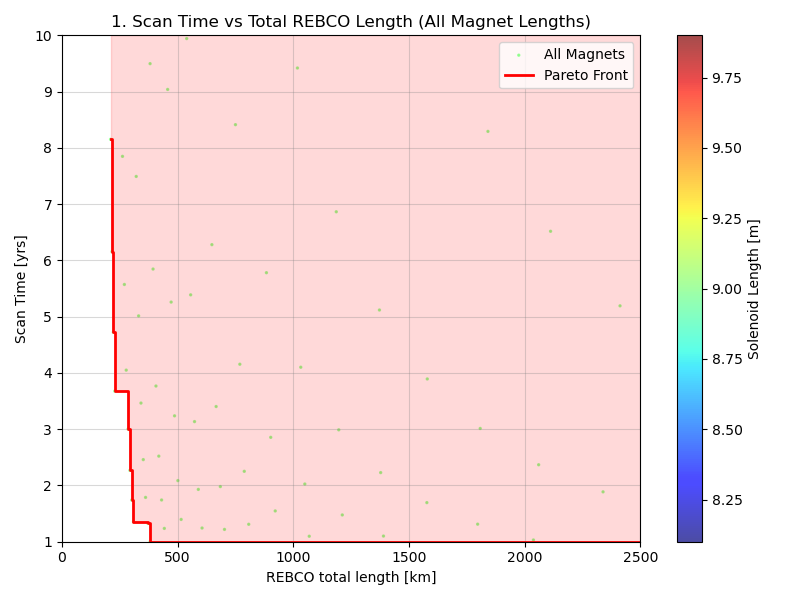

In [366]:
import matplotlib.pyplot as plt
import pandas as pd

# Read your CSV file into the dataframe
df_all = pd.read_csv('thickness_grids_L9000mm.csv')

# Filter ONLY by scan time (1 to 10 years)
df_filtered = df_all[(df_all['scan'] >= 1.0) & (df_all['scan'] <= 10.0)].reset_index(drop=True)

print(f"Total data points to plot: {len(df_filtered)}")

if len(df_filtered) == 0:
    print("No data matches the scan time conditions.")
else:
    # Sort the dataframe to find the Pareto front
    df_sorted = df_filtered.sort_values(by=['length_tape_km', 'scan'])

    # Vectorized Pareto front calculation replacing the slow iterrows loop
    # A point is on the front if its scan time is strictly less than the minimum scan time seen so far
    shifted_cummin = df_sorted['scan'].shift(1).cummin().fillna(float('inf'))
    is_pareto = df_sorted['scan'] < shifted_cummin
    
    pareto_df = df_sorted[is_pareto]
    pareto_x = pareto_df['length_tape_km'].tolist()
    pareto_y = pareto_df['scan'].tolist()

    # Extend the Pareto front to the maximum X value so the fill reaches the right edge
    max_x = df_filtered['length_tape_km'].max()
    if pareto_x:
        pareto_x.append(max_x)
        pareto_y.append(pareto_y[-1])

    fig1, ax1 = plt.subplots(figsize=(8, 6))

    # Scatter plot optimized for large datasets
    # Removed picker=5, added s=2 (smaller markers), and added rasterized=True
    scat1 = ax1.scatter(df_filtered['length_tape_km'], df_filtered['scan'], 
                        c=df_filtered['solenoid_length_m'], cmap='jet', alpha=0.7, 
                        s=2, rasterized=True, label='All Magnets')

    # Add a colorbar to explain the colormap
    cbar = fig1.colorbar(scat1, ax=ax1)
    cbar.set_label('Solenoid Length [m]')

    # Plot the stepped line for the Pareto front
    ax1.plot(pareto_x, pareto_y, drawstyle='steps-post', color='red', linewidth=2, label='Pareto Front')

    # Fill the area ABOVE the Pareto front, up to the maximum y-limit (10.0)
    ax1.fill_between(pareto_x, pareto_y, y2=10.0, step='post', color='red', alpha=0.15)

    ax1.set_xlabel('REBCO total length [km]')
    ax1.set_ylabel('Scan Time [yrs]')
    ax1.set_xlim(0, 2500)
    ax1.set_ylim(1.0, 10.0)
    ax1.set_title('1. Scan Time vs Total REBCO Length (All Magnet Lengths)')
    ax1.grid(True, linestyle='-', color='gray', alpha=0.3)
    ax1.legend()

    fig1.tight_layout()
    plt.show()

/var/folders/8k/rnt65xzx4ml1894t3n7wmjzw0000gn/T/ipykernel_99205/3011140881.py:27: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * x) + c
/var/folders/8k/rnt65xzx4ml1894t3n7wmjzw0000gn/T/ipykernel_99205/3011140881.py:103: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(func, px_unique, py_unique,
/var/folders/8k/rnt65xzx4ml1894t3n7wmjzw0000gn/T/ipykernel_99205/3011140881.py:103: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(func, px_unique, py_unique,
/var/folders/8k/rnt65xzx4ml1894t3n7wmjzw0000gn/T/ipykernel_99205/3011140881.py:103: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(func, px_unique, py_unique,
/var/folders/8k/rnt65xzx4ml1894t3n7wmjzw0000gn/T/ipykernel_99205/3011140881.py:103: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(func, px_unique, py_unique,
/var/folders/8k/rnt65xzx4ml18

Saved 149 Pareto magnets with 22 columns to 'saved_pareto_fronts.csv'
Mathematical fit parameters saved to 'saved_pareto_equations.csv'
Individual plots have been saved as PNG files in the current directory.


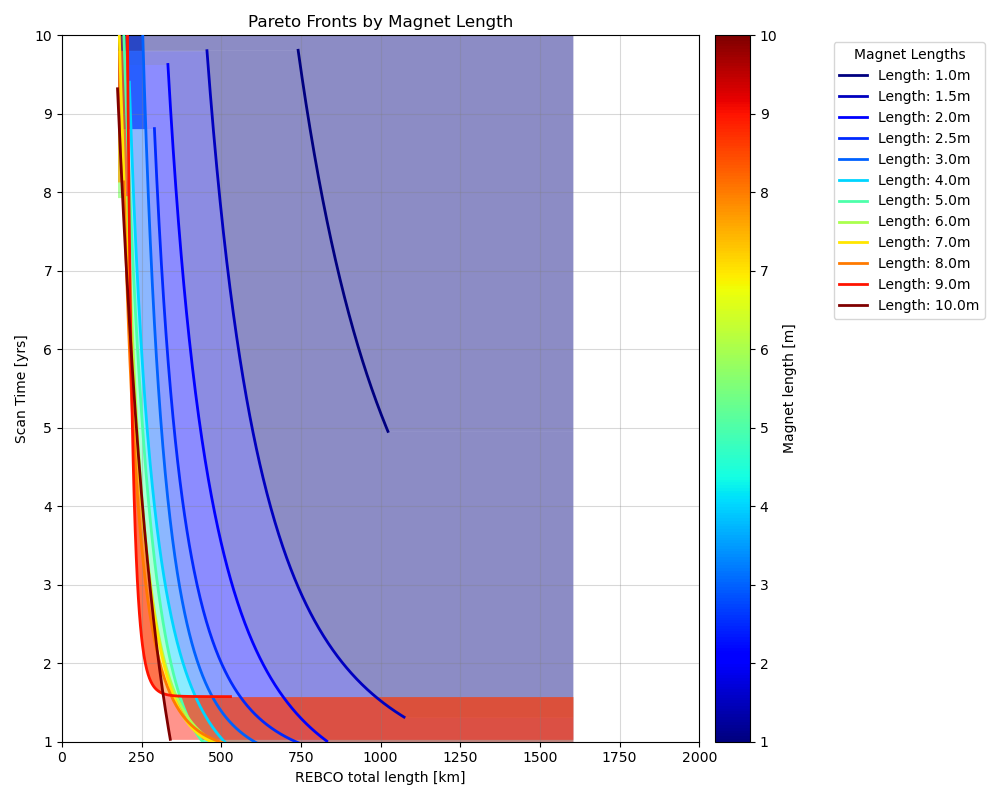

In [368]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import numpy as np
import glob
import os
from scipy.optimize import curve_fit
from scipy.interpolate import PchipInterpolator

# ----------------------------- user settings --------------------------------
CMAP        = plt.cm.jet     # or plt.cm.rainbow / plt.cm.turbo
FILL_ALPHA  = 0.45           # transparency of the bands between two curves
Y_TOP       = 10.0           # top of the plotting window
X_LIM       = (0.0, 2000.0)
FILL_TO_TOP = True           # also shade from the uppermost curve up to Y_TOP
BAND_FROM_LOWER_LENGTH = True  # band takes the colour of the shorter-magnet curve
SAVE_PER_LENGTH_CSV = True   # also write one Pareto CSV per magnet length
# -----------------------------------------------------------------------------


def power_law(x, a, b, c):
    x_safe = np.maximum(x, 1e-5)
    return a * (x_safe ** -b) + c


def exponential_decay(x, a, b, c):
    return a * np.exp(-b * x) + c


file_list = sorted(glob.glob('thickness_grids_L*.csv'))

pareto_tables = []   # list of DataFrames, one per input file (full magnet info)
all_fit_equations = []
curves = []          # everything needed for plotting, filled in pass 1

# =============================================================================
# PASS 1 - read the data, build the Pareto fronts and fit them
# =============================================================================
for file_path in file_list:
    df_all = pd.read_csv(file_path)

    if 'solenoid_length_m' in df_all.columns:
        length_val = df_all['solenoid_length_m'].iloc[0]
        label_name = f'Length: {length_val}m'
    else:
        length_val = os.path.basename(file_path)
        label_name = str(length_val)

    df_filtered = df_all[(df_all['scan'] >= 0.95) &
                         (df_all['scan'] <= 11.0)].reset_index(drop=True)
    if len(df_filtered) == 0:
        continue

    df_sorted = df_filtered.sort_values(by=['length_tape_km', 'scan'])

    # ---- Pareto selection: keep the INDEX of every non-dominated row --------
    pareto_idx = []
    min_y = float('inf')
    for idx, row in df_sorted.iterrows():
        if row['scan'] < min_y:
            pareto_idx.append(idx)
            min_y = row['scan']

    if not pareto_idx:
        continue

    # ---- full rows of the Pareto magnets (every column of the source file) --
    df_pareto = df_sorted.loc[pareto_idx].copy().reset_index(drop=True)
    df_pareto.insert(0, 'source_file', os.path.basename(file_path))
    if 'solenoid_length_m' not in df_pareto.columns:
        df_pareto.insert(1, 'solenoid_length_m', length_val)
    df_pareto.insert(1, 'pareto_rank', np.arange(1, len(df_pareto) + 1))

    pareto_tables.append(df_pareto)

    if SAVE_PER_LENGTH_CSV:
        tag = str(length_val).replace('.', '_').replace('/', '_')
        df_pareto.to_csv(f'pareto_magnets_L{tag}.csv', index=False)

    # ---- arrays used for the fitting / plotting ------------------------------
    px_arr = df_pareto['length_tape_km'].to_numpy(dtype=float)
    py_arr = df_pareto['scan'].to_numpy(dtype=float)

    px_unique, idx_u = np.unique(px_arr, return_index=True)
    py_unique = py_arr[idx_u]

    if len(px_unique) < 2:
        continue

    x_smooth = np.linspace(px_unique.min(), px_unique.max(), 300)
    evaluator = None
    fit_label = ''
    y_curve = None

    if len(px_unique) >= 3:
        best_error = float('inf')
        best_params, best_func, best_name = None, None, ''

        for func, name in ((power_law, 'Power Law'),
                           (exponential_decay, 'Exponential')):
            try:
                p0 = [py_unique.max(), 0.1, py_unique.min()]
                popt, _ = curve_fit(func, px_unique, py_unique,
                                    p0=p0, maxfev=10000)
                residuals = py_unique - func(px_unique, *popt)
                ssr = float(np.sum(residuals ** 2))
                if ssr < best_error:
                    best_error, best_params = ssr, popt
                    best_func, best_name = func, name
            except Exception:
                continue

        if best_func is not None:
            evaluator = (lambda x, f=best_func, p=best_params: f(x, *p))
            fit_label = f'Fit: {best_name}'
            all_fit_equations.append({
                'solenoid_length_m': length_val,
                'function_type': best_name,
                'param_a': best_params[0],
                'param_b': best_params[1],
                'param_c': best_params[2],
                'sum_squared_error': best_error
            })

    if evaluator is None:                      # 2 points, or fitting failed
        spline = PchipInterpolator(px_unique, py_unique)
        evaluator = (lambda x, s=spline: s(x))
        fit_label = 'Fit: Spline (fallback)'
        label_name_plot = label_name + ' (spline)'
    else:
        label_name_plot = label_name

    y_curve = evaluator(x_smooth)

    try:
        sort_value = float(length_val)
    except (TypeError, ValueError):
        sort_value = float('inf')

    curves.append({
        'label':  label_name_plot,
        'length': sort_value,
        'x':      x_smooth,
        'y':      y_curve,
        'eval':   evaluator,
        'xmin':   float(px_unique.min()),
        'xmax':   float(px_unique.max()),
        'px':     px_unique,
        'py':     py_unique,
        'fit_label': fit_label,
    })

# =============================================================================
# Colour mapping: shortest magnet -> one end of jet, longest -> the other end
# =============================================================================
curves.sort(key=lambda c: c['length'])

lengths = np.array([c['length'] for c in curves], dtype=float)
finite = lengths[np.isfinite(lengths)]
if finite.size == 0:
    norm = mpl.colors.Normalize(0, max(len(curves) - 1, 1))
    for k, c in enumerate(curves):
        c['color'] = CMAP(norm(k))
else:
    lo, hi = finite.min(), finite.max()
    if lo == hi:
        lo, hi = lo - 0.5, hi + 0.5
    norm = mpl.colors.Normalize(vmin=lo, vmax=hi)
    for c in curves:
        v = c['length'] if np.isfinite(c['length']) else hi
        c['color'] = CMAP(norm(v))

# =============================================================================
# PASS 2 - aggregate figure: bands between neighbouring curves + the lines
# =============================================================================
fig1, ax1 = plt.subplots(figsize=(10, 8))

if curves:
    # common grid so that neighbouring curves can be filled against each other
    x_common = np.linspace(min(c['xmin'] for c in curves),
                           max(c['xmax'] for c in curves), 800)
    # constant extrapolation outside each curve's own data range
    Y = np.vstack([c['eval'](np.clip(x_common, c['xmin'], c['xmax']))
                   for c in curves])

    # shade the region between every pair of neighbouring Pareto fronts
    for i in range(len(curves) - 1):
        band_color = curves[i]['color'] if BAND_FROM_LOWER_LENGTH \
                     else curves[i + 1]['color']
        ax1.fill_between(x_common, Y[i], Y[i + 1],
                         color=band_color, alpha=FILL_ALPHA,
                         linewidth=0, zorder=1)

    # shade from the uppermost curve to the top of the axes with its own colour
    if FILL_TO_TOP:
        top_idx = int(np.argmax(np.nanmean(Y, axis=1)))
        ax1.fill_between(x_common, Y[top_idx], Y_TOP,
                         color=curves[top_idx]['color'], alpha=FILL_ALPHA,
                         linewidth=0, zorder=1)

    # the fitted lines on top
    handles, labels = [], []
    for c in curves:
        ln, = ax1.plot(c['x'], c['y'], color=c['color'],
                       linewidth=2, label=c['label'], zorder=3)
        handles.append(ln)
        labels.append(c['label'])

# ---------------------------- individual plots -------------------------------
for c in curves:
    fig_ind, ax_ind = plt.subplots(figsize=(8, 6))
    ax_ind.scatter(c['px'], c['py'], color='black',
                   label='Pareto Points', zorder=4)
    ax_ind.plot(c['x'], c['y'], color=c['color'], linewidth=2,
                label=c['fit_label'], zorder=3)
    ax_ind.set_xlabel('REBCO total length [km]')
    ax_ind.set_ylabel('Scan Time [yrs]')
    ax_ind.set_title(f"Pareto Front and Fit - {c['label']}")
    ax_ind.grid(True, linestyle='-', color='gray', alpha=0.3, zorder=1)
    ax_ind.legend()
    fig_ind.tight_layout()
    safe_filename = str(c['length']).replace('.', '_').replace('/', '_')
    fig_ind.savefig(f'individual_fit_{safe_filename}.png', dpi=150)
    plt.close(fig_ind)

# ------------------------------- CSV output ----------------------------------
if pareto_tables:
    df_pareto_all = pd.concat(pareto_tables, ignore_index=True, sort=False)

    # keep the identifying columns first, then everything else from the source
    lead = [c for c in ('source_file', 'pareto_rank', 'solenoid_length_m',
                        'length_tape_km', 'scan') if c in df_pareto_all.columns]
    rest = [c for c in df_pareto_all.columns if c not in lead]
    df_pareto_all = df_pareto_all[lead + rest]

    df_pareto_all.to_csv('saved_pareto_fronts.csv', index=False)
    print(f"Saved {len(df_pareto_all)} Pareto magnets with "
          f"{df_pareto_all.shape[1]} columns to 'saved_pareto_fronts.csv'")

    if all_fit_equations:
        pd.DataFrame(all_fit_equations).to_csv('saved_pareto_equations.csv',
                                               index=False)
        print("Mathematical fit parameters saved to 'saved_pareto_equations.csv'")
else:
    print("No Pareto points were generated to save.")

print("Individual plots have been saved as PNG files in the current directory.")

# ------------------------------- cosmetics -----------------------------------
ax1.set_xlabel('REBCO total length [km]')
ax1.set_ylabel('Scan Time [yrs]')
ax1.set_xlim(*X_LIM)
ax1.set_ylim(1.0, Y_TOP)
ax1.set_title('Pareto Fronts by Magnet Length')
ax1.grid(True, linestyle='-', color='gray', alpha=0.3, zorder=2)

sm = mpl.cm.ScalarMappable(norm=norm, cmap=CMAP)
sm.set_array([])
cbar = fig1.colorbar(sm, ax=ax1, pad=0.02)
cbar.set_label('Magnet length [m]')

ax1.legend(handles, labels, title='Magnet Lengths',
           bbox_to_anchor=(1.20, 1), loc='upper left')

fig1.tight_layout()
plt.show()

/var/folders/8k/rnt65xzx4ml1894t3n7wmjzw0000gn/T/ipykernel_99205/1390964924.py:32: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * x) + c
/var/folders/8k/rnt65xzx4ml1894t3n7wmjzw0000gn/T/ipykernel_99205/1390964924.py:122: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(func, px_unique, py_unique,
/var/folders/8k/rnt65xzx4ml1894t3n7wmjzw0000gn/T/ipykernel_99205/1390964924.py:122: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(func, px_unique, py_unique,
/var/folders/8k/rnt65xzx4ml1894t3n7wmjzw0000gn/T/ipykernel_99205/1390964924.py:122: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(func, px_unique, py_unique,
/var/folders/8k/rnt65xzx4ml1894t3n7wmjzw0000gn/T/ipykernel_99205/1390964924.py:122: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(func, px_unique, py_unique,
/var/folders/8k/rnt65xzx4ml18

Saved 149 Pareto points with 22 columns to 'saved_pareto_fronts.csv'
  columns: source_file, pareto_rank, solenoid_length_m, length_tape_km, scan, row_i, col_j, ri, rf, th, v, v_bore, b0, je_tape, je_max, je_coil, stress, length_tape, j_crit, converged, f_tape_min, pancake_length_m
Fit parameters (with validity range) saved to 'saved_pareto_equations.csv'
Individual plots have been saved as PNG files in the current directory.


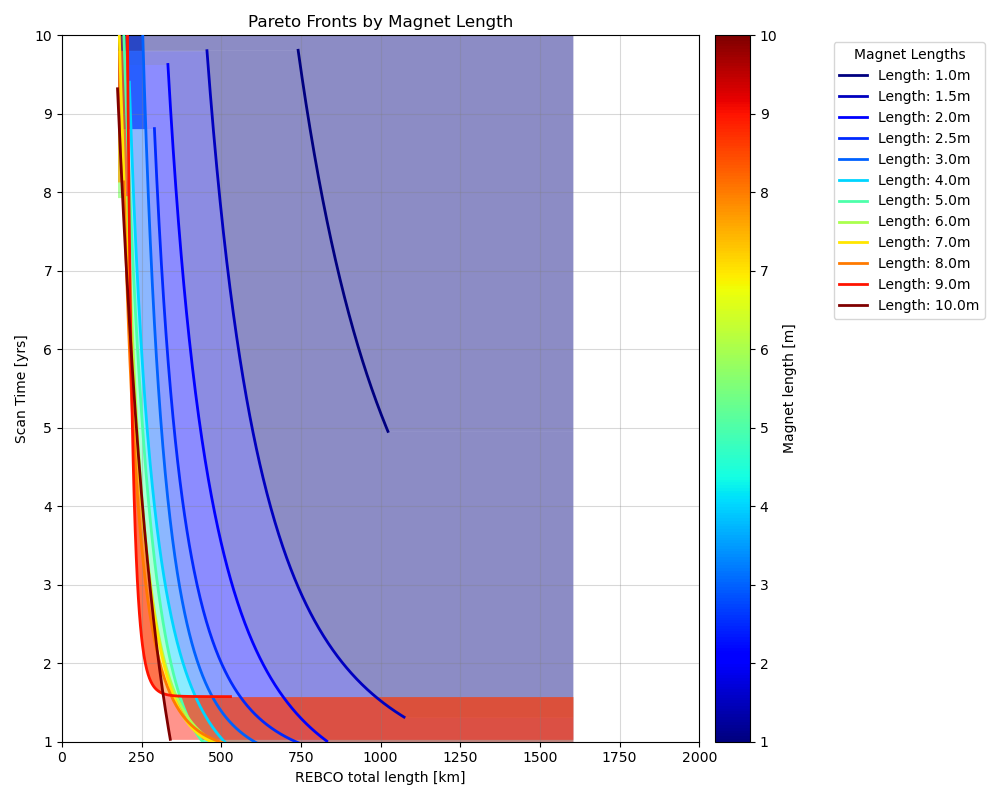

In [369]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import numpy as np
import glob
import os
import re
from scipy.optimize import curve_fit
from scipy.interpolate import PchipInterpolator

# ----------------------------- user settings --------------------------------
CMAP        = plt.cm.jet       # or plt.cm.rainbow / plt.cm.turbo
FILL_ALPHA  = 0.45             # transparency of the bands between two curves
Y_TOP       = 10.0             # top of the plotting window
Y_BOTTOM    = 1.0
X_LIM       = (0.0, 2000.0)
FILL_TO_TOP = True             # also shade from the uppermost curve up to Y_TOP
BAND_FROM_LOWER_LENGTH = True  # band takes the colour of the shorter-magnet curve
SCAN_MIN, SCAN_MAX = 0.95, 11.0
KEEP_TIES   = False            # keep every design that ties on the objectives
EXPORT_COLUMNS = None          # None = save every column of the grid file,
                               # or e.g. ['length_tape_km', 'scan', 'thickness_m']
# -----------------------------------------------------------------------------


def power_law(x, a, b, c):
    x_safe = np.maximum(x, 1e-5)
    return a * (x_safe ** -b) + c


def exponential_decay(x, a, b, c):
    return a * np.exp(-b * x) + c


def safe_tag(text):
    """Filesystem-safe token used for the individual figure filenames."""
    return re.sub(r'[^0-9A-Za-z_-]+', '_', str(text)).strip('_')


file_list = sorted(glob.glob('thickness_grids_L*.csv'))
if not file_list:
    raise SystemExit("No files matching 'thickness_grids_L*.csv' were found.")

all_pareto_frames = []   # full grid rows of the non-dominated designs
all_fit_equations = []   # fitted coefficients + validity range
curves = []              # everything needed for plotting, filled in pass 1

# =============================================================================
# PASS 1 - read the data, build the Pareto fronts and fit them
# =============================================================================
for file_path in file_list:
    df_all = pd.read_csv(file_path)
    base_name = os.path.basename(file_path)

    missing = {'length_tape_km', 'scan'} - set(df_all.columns)
    if missing:
        print(f"  skipping {base_name}: missing column(s) {sorted(missing)}")
        continue

    if 'solenoid_length_m' in df_all.columns:
        length_val = df_all['solenoid_length_m'].iloc[0]
        label_name = f'Length: {length_val}m'
    else:
        length_val = base_name
        label_name = str(length_val)

    df_filtered = df_all[(df_all['scan'] >= SCAN_MIN) &
                         (df_all['scan'] <= SCAN_MAX)].reset_index(drop=True)
    if len(df_filtered) == 0:
        print(f"  skipping {base_name}: no rows inside the scan-time window")
        continue

    df_sorted = df_filtered.sort_values(by=['length_tape_km', 'scan'])

    # ---- dominance filter: keep the row indices, not just the coordinates ----
    pareto_idx = []
    min_y = float('inf')
    for index, row in df_sorted.iterrows():
        y = row['scan']
        if y < min_y:
            pareto_idx.append(index)
            min_y = y
        elif KEEP_TIES and y == min_y:
            pareto_idx.append(index)

    if not pareto_idx:
        continue

    # ---- this frame carries EVERY column of the grid file -------------------
    df_pareto = df_sorted.loc[pareto_idx].copy()
    if EXPORT_COLUMNS is not None:
        keep = [c for c in EXPORT_COLUMNS if c in df_pareto.columns]
        df_pareto = df_pareto[keep]
    df_pareto['solenoid_length_m'] = length_val   # guarantee the column exists
    df_pareto.insert(0, 'source_file', base_name)
    df_pareto.insert(1, 'pareto_rank', np.arange(len(df_pareto)))
    all_pareto_frames.append(df_pareto)

    px_arr = df_pareto['length_tape_km'].to_numpy(dtype=float)
    py_arr = df_pareto['scan'].to_numpy(dtype=float)

    px_unique, idx = np.unique(px_arr, return_index=True)
    py_unique = py_arr[idx]

    if len(px_unique) < 2:
        print(f"  {base_name}: only {len(px_unique)} unique point(s), no curve drawn")
        continue

    # ------------------------------- fitting ---------------------------------
    x_smooth = np.linspace(px_unique.min(), px_unique.max(), 300)
    evaluator = None
    fit_label = ''

    if len(px_unique) >= 3:
        best_error = float('inf')
        best_params, best_func, best_name = None, None, ''

        for func, name in ((power_law, 'Power Law'),
                           (exponential_decay, 'Exponential')):
            try:
                p0 = [py_unique.max(), 0.1, py_unique.min()]
                popt, _ = curve_fit(func, px_unique, py_unique,
                                    p0=p0, maxfev=10000)
                residuals = py_unique - func(px_unique, *popt)
                ssr = float(np.sum(residuals ** 2))
                if np.isfinite(ssr) and ssr < best_error:
                    best_error, best_params = ssr, popt
                    best_func, best_name = func, name
            except Exception:
                continue

        if best_func is not None:
            evaluator = (lambda x, f=best_func, p=best_params: f(x, *p))
            fit_label = f'Fit: {best_name}'
            all_fit_equations.append({
                'source_file': base_name,
                'solenoid_length_m': length_val,
                'function_type': best_name,
                'param_a': float(best_params[0]),
                'param_b': float(best_params[1]),
                'param_c': float(best_params[2]),
                'sum_squared_error': best_error,
                'rmse': float(np.sqrt(best_error / len(px_unique))),
                'x_fit_min': float(px_unique.min()),
                'x_fit_max': float(px_unique.max()),
                'n_points': int(len(px_unique)),
            })

    if evaluator is None:                      # 2 points, or fitting failed
        spline = PchipInterpolator(px_unique, py_unique)
        evaluator = (lambda x, s=spline: s(x))
        fit_label = 'Fit: Spline (fallback)'
        label_name_plot = label_name + ' (spline)'
    else:
        label_name_plot = label_name

    try:
        sort_value = float(length_val)
    except (TypeError, ValueError):
        sort_value = float('inf')

    curves.append({
        'label':     label_name_plot,
        'tag':       safe_tag(length_val),
        'length':    sort_value,
        'x':         x_smooth,
        'y':         evaluator(x_smooth),
        'eval':      evaluator,
        'xmin':      float(px_unique.min()),
        'xmax':      float(px_unique.max()),
        'px':        px_unique,
        'py':        py_unique,
        'fit_label': fit_label,
    })

# =============================================================================
# CSV output - the full design vector of every Pareto-optimal magnet
# =============================================================================
if all_pareto_frames:
    df_saved = pd.concat(all_pareto_frames, ignore_index=True)

    front_cols = [c for c in ('source_file', 'pareto_rank', 'solenoid_length_m',
                              'length_tape_km', 'scan') if c in df_saved.columns]
    other_cols = [c for c in df_saved.columns if c not in front_cols]
    df_saved = df_saved[front_cols + other_cols]
    df_saved = df_saved.sort_values(['solenoid_length_m', 'length_tape_km'],
                                    kind='mergesort').reset_index(drop=True)

    df_saved.to_csv('saved_pareto_fronts.csv', index=False)
    print(f"Saved {len(df_saved)} Pareto points with {df_saved.shape[1]} columns "
          f"to 'saved_pareto_fronts.csv'")
    print("  columns: " + ", ".join(df_saved.columns))

    if all_fit_equations:
        pd.DataFrame(all_fit_equations).to_csv('saved_pareto_equations.csv',
                                               index=False)
        print("Fit parameters (with validity range) saved to "
              "'saved_pareto_equations.csv'")
else:
    print("No Pareto points were generated to save.")

# =============================================================================
# Colour mapping: shortest magnet -> one end of jet, longest -> the other end
# =============================================================================
curves.sort(key=lambda c: c['length'])

norm = None
if curves:
    lengths = np.array([c['length'] for c in curves], dtype=float)
    finite = lengths[np.isfinite(lengths)]
    if finite.size == 0:
        norm = mpl.colors.Normalize(0, max(len(curves) - 1, 1))
        for k, c in enumerate(curves):
            c['color'] = CMAP(norm(k))
    else:
        lo, hi = float(finite.min()), float(finite.max())
        if lo == hi:
            lo, hi = lo - 0.5, hi + 0.5
        norm = mpl.colors.Normalize(vmin=lo, vmax=hi)
        for c in curves:
            v = c['length'] if np.isfinite(c['length']) else hi
            c['color'] = CMAP(norm(v))

# =============================================================================
# PASS 2 - aggregate figure: bands between neighbouring curves + the lines
# =============================================================================
fig1, ax1 = plt.subplots(figsize=(10, 8))
handles, labels = [], []

if curves:
    # common grid so that neighbouring curves can be filled against each other
    x_common = np.linspace(min(c['xmin'] for c in curves),
                           max(c['xmax'] for c in curves), 800)
    # constant extrapolation outside each curve's own data range
    Y = np.vstack([c['eval'](np.clip(x_common, c['xmin'], c['xmax']))
                   for c in curves])

    for i in range(len(curves) - 1):
        band_color = curves[i]['color'] if BAND_FROM_LOWER_LENGTH \
                     else curves[i + 1]['color']
        ax1.fill_between(x_common, Y[i], Y[i + 1],
                         color=band_color, alpha=FILL_ALPHA,
                         linewidth=0, zorder=1)

    if FILL_TO_TOP and len(curves) > 0:
        top_idx = int(np.argmax(np.nanmean(Y, axis=1)))
        ax1.fill_between(x_common, Y[top_idx], Y_TOP,
                         color=curves[top_idx]['color'], alpha=FILL_ALPHA,
                         linewidth=0, zorder=1)

    for c in curves:
        ln, = ax1.plot(c['x'], c['y'], color=c['color'],
                       linewidth=2, label=c['label'], zorder=3)
        handles.append(ln)
        labels.append(c['label'])

# ---------------------------- individual plots -------------------------------
for c in curves:
    fig_ind, ax_ind = plt.subplots(figsize=(8, 6))
    ax_ind.scatter(c['px'], c['py'], color='black',
                   label='Pareto Points', zorder=4)
    ax_ind.plot(c['x'], c['y'], color=c['color'], linewidth=2,
                label=c['fit_label'], zorder=3)
    ax_ind.set_xlabel('REBCO total length [km]')
    ax_ind.set_ylabel('Scan Time [yrs]')
    ax_ind.set_title(f"Pareto Front and Fit - {c['label']}")
    ax_ind.grid(True, linestyle='-', color='gray', alpha=0.3, zorder=1)
    ax_ind.legend()
    fig_ind.tight_layout()
    fig_ind.savefig(f"individual_fit_{c['tag']}.png", dpi=150)
    plt.close(fig_ind)

print("Individual plots have been saved as PNG files in the current directory.")

# ------------------------------- cosmetics -----------------------------------
ax1.set_xlabel('REBCO total length [km]')
ax1.set_ylabel('Scan Time [yrs]')
ax1.set_xlim(*X_LIM)
ax1.set_ylim(Y_BOTTOM, Y_TOP)
ax1.set_title('Pareto Fronts by Magnet Length')
ax1.grid(True, linestyle='-', color='gray', alpha=0.3, zorder=2)

if norm is not None:
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=CMAP)
    sm.set_array([])
    cbar = fig1.colorbar(sm, ax=ax1, pad=0.02)
    cbar.set_label('Magnet length [m]')

if handles:
    ax1.legend(handles, labels, title='Magnet Lengths',
               bbox_to_anchor=(1.20, 1), loc='upper left')

fig1.tight_layout()
plt.show()

In [ ]:
import importlib
import math
import solenoid_lib


importlib.reload(solenoid_lib)


from solenoid_lib import scan_time, dB_to_eta

# Magnet / bore geometry
B0_baseline = 18          # T
l_bore      = 8.5         # m
d_bore      = 0.090       # m
V_m3        = math.pi * (d_bore / 2)**2 * l_bore   # bore volume [m^3]
print(f"Bore volume: {V_m3:.4f} m^3")

s_per_year = 365.25 * 24 * 3600


print(f"{'Scenario':<40} {'Expected':>10}  {'DFSZ':>10} {'Ratio':>10}")
print("-" * 74)

scenarios = [
    (16, 10, 20e6, -20, 6.2,  'Baseline'),
    (29, 10, 20e6, -5,  3.2,  'Stronger magnet + higher noise'),
    (16,  8, 20e6, -25, 7.3,  'Lower noise + lower volume'),
    (16, 17,  2e6, -20, 10.6, 'Higher volume + lower Q'),
    (26, 10,  2e6, -20, 8.9,  'Stronger magnet + lower Q'),
    (B0_baseline, V_m3, 20e6, -20, 2.24,  'CORE-GUT')
]

for (B0, V_m3, Q, eta_dB, expected, name) in scenarios:
    eta_A  = dB_to_eta(eta_dB)
    t_dfsz = scan_time(B0, V_m3, Q=Q, eta_A=eta_A, model='DFSZ')
    ratio  = expected / t_dfsz
    print(f"{name:<40} {expected:>10.1f} {t_dfsz:>10.2f} {ratio:>10.3f}")